# Data exploration — basic EDA

Goal: get a first look at the Santos 2024 SSS dataset.

- How many images, how many are annotated, breakdown by year.
- Class balance: MILCO (mine) vs NOMBO (non-mine).
- What a raw SSS image looks like.
- How the YOLO bounding boxes overlay on an image.
- Side-by-side: a MILCO example, a NOMBO example, and an unlabeled image.

Deferred to a later pass: bbox size/aspect distributions, intensity statistics, speckle/range-falloff characterisation.

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

DATA_ROOT = Path("../data/santos").resolve()
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"
CLASS_NAMES = ["MILCO", "NOMBO"]
CLASS_COLORS = {0: "tab:red", 1: "tab:cyan"}

assert IMAGES_DIR.is_dir() and LABELS_DIR.is_dir(), f"missing {IMAGES_DIR} or {LABELS_DIR}"
print(f"images: {IMAGES_DIR}")
print(f"labels: {LABELS_DIR}")

images: /Users/adityakoushik/Desktop/sonar_mines/data/santos/images
labels: /Users/adityakoushik/Desktop/sonar_mines/data/santos/labels


## Index the dataset

Build a small record per image: path, year (parsed from the filename suffix), and list of bounding-box rows. An empty label file means the image has no annotated objects.

In [2]:
@dataclass
class Sample:
    stem: str
    year: int
    image_path: Path
    label_path: Path
    boxes: list[tuple[int, float, float, float, float]]  # (cls, cx, cy, w, h) in [0, 1]

    @property
    def annotated(self) -> bool:
        return len(self.boxes) > 0


def parse_label(path: Path) -> list[tuple[int, float, float, float, float]]:
    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        cls, cx, cy, w, h = line.split()
        rows.append((int(cls), float(cx), float(cy), float(w), float(h)))
    return rows


samples: list[Sample] = []
for img_path in sorted(IMAGES_DIR.glob("*.jpg")):
    stem = img_path.stem                       # e.g. "0001_2010"
    year = int(stem.rsplit("_", 1)[-1])
    lbl_path = LABELS_DIR / f"{stem}.txt"
    samples.append(Sample(stem, year, img_path, lbl_path, parse_label(lbl_path)))

print(f"total samples: {len(samples)}")
print(f"annotated:     {sum(s.annotated for s in samples)}")
print(f"unlabeled:     {sum(not s.annotated for s in samples)}")

total samples: 1170
annotated:     304
unlabeled:     866


## Counts per year and per class

The dataset is collected across five years (2010, 2015, 2017, 2018, 2021). Most images are unlabeled — only 304 carry bounding boxes — and within those, the two classes (MILCO mines, NOMBO non-mines) are unbalanced.

In [3]:
per_year_total = Counter(s.year for s in samples)
per_year_annot = Counter(s.year for s in samples if s.annotated)
years = sorted(per_year_total)

print(f"{'year':>6} {'total':>8} {'annotated':>12} {'unlabeled':>12}")
for y in years:
    t, a = per_year_total[y], per_year_annot[y]
    print(f"{y:>6} {t:>8} {a:>12} {t - a:>12}")

object_counts = Counter(box[0] for s in samples for box in s.boxes)
print()
print("objects across all annotated images:")
for cls_id, name in enumerate(CLASS_NAMES):
    print(f"  {name:<6} (cls={cls_id}): {object_counts[cls_id]}")
print(f"  total objects: {sum(object_counts.values())}")

  year    total    annotated    unlabeled
  2010      345           28          317
  2015      120          118            2
  2017       93           19           74
  2018      564          112          452
  2021       48           27           21

objects across all annotated images:
  MILCO  (cls=0): 437
  NOMBO  (cls=1): 231
  total objects: 668


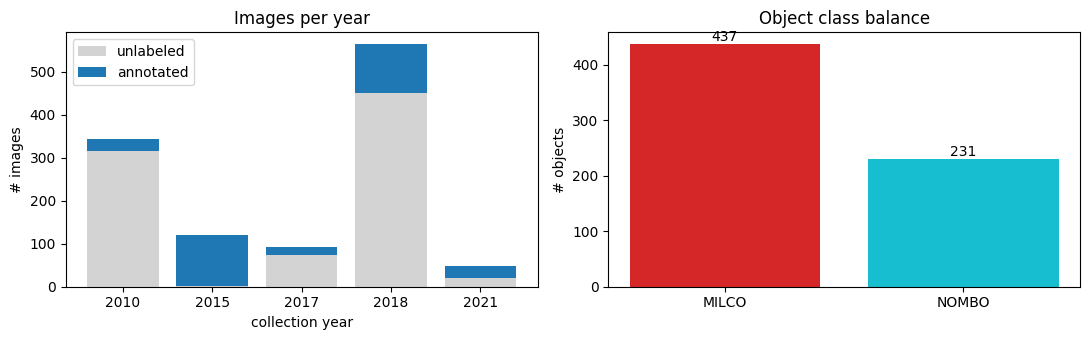

In [4]:
fig, (ax_year, ax_class) = plt.subplots(1, 2, figsize=(11, 3.5))

annot_per_year = [per_year_annot[y] for y in years]
unlab_per_year = [per_year_total[y] - per_year_annot[y] for y in years]
x = np.arange(len(years))
ax_year.bar(x, unlab_per_year, label="unlabeled", color="lightgray")
ax_year.bar(x, annot_per_year, bottom=unlab_per_year, label="annotated", color="tab:blue")
ax_year.set_xticks(x, [str(y) for y in years])
ax_year.set_xlabel("collection year")
ax_year.set_ylabel("# images")
ax_year.set_title("Images per year")
ax_year.legend()

cls_ids = list(range(len(CLASS_NAMES)))
ax_class.bar(cls_ids, [object_counts[c] for c in cls_ids],
             color=[CLASS_COLORS[c] for c in cls_ids])
ax_class.set_xticks(cls_ids, CLASS_NAMES)
ax_class.set_ylabel("# objects")
ax_class.set_title("Object class balance")
for c in cls_ids:
    ax_class.text(c, object_counts[c], str(object_counts[c]), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## What does an image look like?

A single raw SSS frame. Side-scan sonar images are essentially intensity rasters — the sensor moves along-track (vertical axis) and pings out to either side, so the horizontal axis is range. Bright = strong return, dark = acoustic shadow.

file:   0001_2015.jpg
shape:  (1024, 1024, 3)  (H, W, C)
dtype:  uint8
min/max intensity: 0 / 255


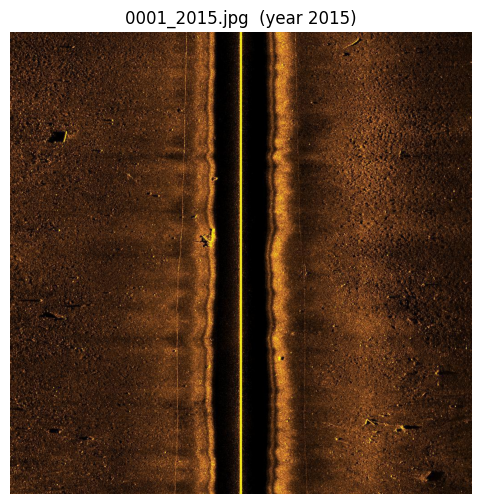

In [5]:
sample = next(s for s in samples if s.annotated)
img = np.array(Image.open(sample.image_path))

print(f"file:   {sample.image_path.name}")
print(f"shape:  {img.shape}  (H, W{'' if img.ndim == 2 else ', C'})")
print(f"dtype:  {img.dtype}")
print(f"min/max intensity: {img.min()} / {img.max()}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img, cmap="gray")
ax.set_title(f"{sample.image_path.name}  (year {sample.year})")
ax.axis("off")
plt.show()

## Overlay bounding boxes

Labels are in YOLO format — each line is `class_id cx cy w h`, all in normalized image coordinates. Multiplying back by `(W, H)` gives pixel coordinates we can draw with.

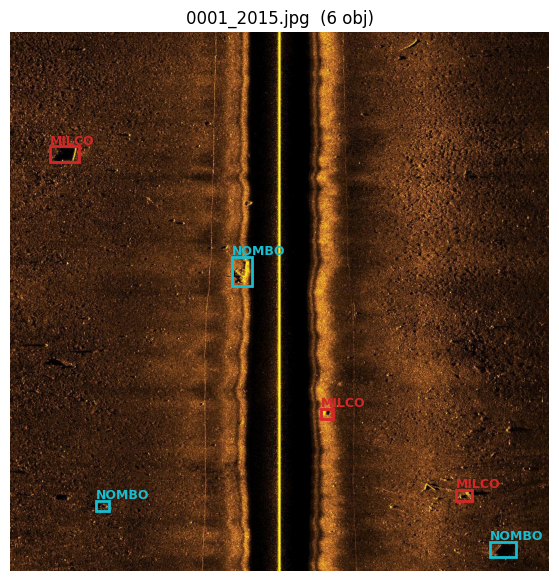

In [6]:
def show_with_boxes(ax, sample: Sample) -> None:
    img = np.array(Image.open(sample.image_path))
    H, W = img.shape[:2]
    ax.imshow(img, cmap="gray")
    for cls, cx, cy, w, h in sample.boxes:
        x0 = (cx - w / 2) * W
        y0 = (cy - h / 2) * H
        ax.add_patch(patches.Rectangle(
            (x0, y0), w * W, h * H,
            fill=False, edgecolor=CLASS_COLORS[cls], linewidth=2,
        ))
        ax.text(x0, y0 - 4, CLASS_NAMES[cls],
                color=CLASS_COLORS[cls], fontsize=9, weight="bold")
    ax.set_title(f"{sample.image_path.name}  ({len(sample.boxes)} obj)")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 7))
show_with_boxes(ax, sample)
plt.show()

## Random annotated sample

Re-run this cell to draw a fresh example from the 304 annotated images. Each box is labelled with its class (MILCO mine / NOMBO non-mine) using the same color coding as the bar chart above.